# Composite MomentumSector + RegimeSwitching — Research Notebook

> **Strategy #43** | [Composite FF+AW](research_composite_ff_aw.ipynb) · **Composite Mom+Regime**

## Objectifs
- Combiner **SectorMomentum** (rotation SPY/TLT/GLD par momentum composite 1-12m) avec **RegimeSwitching** (filtre bull/bear/sideways via SMA50/SMA200)
- Architecture inspiree de `Framework_Composite_TrendWeather` (Sharpe 1.155)
- SectorMomentum : composite momentum multi-lookback (1m 40% / 3m 20% / 6m 20% / 12m 20%), rotation mensuelle
- RegimeSwitching : momentum en bull, mean-reversion RSI en bear/sideways, allocation defensive
- Sweep allocation SM50-RS50 a SM80-RS20
- Walk-forward 5-fold, 4 seeds (0/1/7/42), verdict honnete

## Architecture
| Composant | Allocation | Signal |
|-----------|------------|--------|
| SectorMomentum | 50-80% | Composite momentum SPY/IEF/GLD, rotation mensuelle |
| RegimeSwitching | 20-50% | Bull=momentum, Bear/Sideways=mean-reversion RSI+defensive |

**Cible** : Sharpe > 0.7 sur 2015-2025. Baseline = SPY B&H.

**Duree estimee** : ~2 min | **Prerequis** : pandas, numpy

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RESEARCH_DIR = Path(".")
DATASET_DIR = RESEARCH_DIR.parent / "datasets" / "panier"
SEEDS = [0, 1, 7, 42]
N_SPLITS = 5
FEE_BPS = 5

# SectorMomentum universe
SM_TICKERS = ["SPY", "IEF", "GLD"]  # TLT replaced by IEF (2022 lesson)
SM_LOOKBACKS = [21, 63, 126, 252]
SM_WEIGHTS = [0.4, 0.2, 0.2, 0.2]

# RegimeSwitching universe
RS_TICKERS = ["SPY", "QQQ", "IEF", "GLD"]
RS_RISKY = ["SPY", "QQQ"]
RS_DEFENSIVE = ["IEF", "GLD"]

print(f"SectorMomentum: {SM_TICKERS}")
print(f"RegimeSwitching: risky={RS_RISKY}, defensive={RS_DEFENSIVE}")

SectorMomentum: ['SPY', 'IEF', 'GLD']
RegimeSwitching: risky=['SPY', 'QQQ'], defensive=['IEF', 'GLD']


## 1. Chargement des donnees

In [2]:
def load_prices(tickers):
    panier_path = DATASET_DIR / "panier_close_all.csv"
    prices = {}
    if panier_path.exists():
        df = pd.read_csv(panier_path, index_col=0, parse_dates=True)
        for t in tickers:
            if t in df.columns:
                prices[t] = df[t].dropna()
    missing = [t for t in tickers if t not in prices]
    if missing:
        try:
            import yfinance as yf
            data = yf.download(missing, start="2010-01-01", end="2026-05-01", auto_adjust=True)["Close"]
            if len(missing) == 1:
                data = data.to_frame(missing[0])
            for t in missing:
                prices[t] = data[t].dropna()
        except Exception:
            pass
    price_df = pd.DataFrame(prices).sort_index().ffill().dropna()
    price_df.index = pd.DatetimeIndex(price_df.index)
    print(f"Loaded: {price_df.shape[1]} tickers, {price_df.shape[0]} days [{price_df.index.min().date()} .. {price_df.index.max().date()}]")
    return price_df

all_tickers = list(set(SM_TICKERS + RS_TICKERS))
prices = load_prices(all_tickers)
prices.head()

[                       0%                       ]

[**********************50%                       ]  2 of 4 completed

[**********************75%***********            ]  3 of 4 completed

[*********************100%***********************]  4 of 4 completed

Loaded: 4 tickers, 4106 days [2010-01-04 .. 2026-04-30]


,IEF,QQQ,GLD,SPY
Date,,,,
2010-01-04,61.548901,40.290791,109.800003,84.796387
2010-01-05,61.819103,40.290791,109.699997,85.020821
2010-01-06,61.569653,40.047764,111.510002,85.080704
2010-01-07,61.569653,40.073792,110.820000,85.439880
2010-01-08,61.645866,40.403618,111.370003,85.724182


## 2. Signaux SectorMomentum et RegimeSwitching

**SectorMomentum** : composite momentum multi-lookback (1m/3m/6m/12m, poids 0.4/0.2/0.2/0.2). Top ticker par momentum, filtre SMA200.

**RegimeSwitching** : detection regime via SPY vs SMA50/SMA200. Bull=momentum risque-ajuste sur risky, Bear/Sideways=mean-reversion RSI+defensive.

In [3]:
def compute_sm_signal(prices, tickers=SM_TICKERS, lookbacks=SM_LOOKBACKS, weights=SM_WEIGHTS):
    """SectorMomentum: composite momentum score per ticker per day."""
    scores = pd.DataFrame(index=prices.index, columns=tickers, dtype=float)
    for t in tickers:
        if t not in prices.columns:
            continue
        close = prices[t]
        score = pd.Series(0.0, index=prices.index)
        for lb, w in zip(lookbacks, weights):
            mom = close / close.shift(lb) - 1
            score += w * mom
        scores[t] = score
    return scores


def compute_regime(prices, sma_short=50, sma_long=200):
    """Detect market regime: bull/bear/sideways based on SPY vs SMA50/SMA200."""
    if "SPY" not in prices.columns:
        return pd.Series("bull", index=prices.index)
    spy = prices["SPY"]
    sma_s = spy.rolling(sma_short, min_periods=sma_short).mean()
    sma_l = spy.rolling(sma_long, min_periods=sma_long).mean()
    regime = pd.Series("sideways", index=prices.index)
    regime[(spy > sma_l) & (sma_s > sma_l)] = "bull"
    regime[(spy < sma_l) & (sma_s < sma_l)] = "bear"
    return regime


def compute_rsi(close, period=14):
    """Compute RSI."""
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period, min_periods=period).mean()
    loss = -delta.clip(upper=0).rolling(period, min_periods=period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


sm_scores = compute_sm_signal(prices)
regime = compute_regime(prices)

print(f"SM scores shape: {sm_scores.shape}")
regime_counts = regime.value_counts()
print(f"Regime distribution: {dict(regime_counts)}")

SM scores shape: (4106, 3)
Regime distribution: {'bull': np.int64(3098), 'sideways': np.int64(572), 'bear': np.int64(436)}


## 3. Strategie composite avec walk-forward

SM sleeve: top ticker par composite momentum. RS sleeve: momentum en bull, mean-reversion+defensive en bear/sideways.

In [4]:
def walk_forward_composite_mr(prices, sm_alloc, seed=0):
    """Walk-forward for SectorMomentum + RegimeSwitching composite.
    
    sm_alloc: fraction for SectorMomentum sleeve (0.5 to 0.8)
    rs_alloc: 1 - sm_alloc for RegimeSwitching sleeve
    """
    np.random.seed(seed)
    rs_alloc = 1.0 - sm_alloc
    
    sm_scores = compute_sm_signal(prices)
    regime = compute_regime(prices)
    rsi_spy = compute_rsi(prices["SPY"]) if "SPY" in prices.columns else None
    rsi_qqq = compute_rsi(prices["QQQ"]) if "QQQ" in prices.columns else None
    spy_sma200 = prices["SPY"].rolling(200, min_periods=200).mean() if "SPY" in prices.columns else None
    
    returns = prices.pct_change().shift(-1)
    n = len(prices)
    fold_size = n // (N_SPLITS + 1)
    if fold_size < 300:
        return None
    
    all_dates = []
    all_port_ret = []
    all_spy_ret = []
    
    for k in range(1, N_SPLITS + 1):
        tr_end = fold_size * k
        te_end = min(tr_end + fold_size, n)
        if te_end - tr_end < 60:
            continue
        
        for i in range(tr_end, te_end):
            date = prices.index[i]
            row_sm = sm_scores.iloc[i] if i < len(sm_scores) else None
            cur_regime = regime.iloc[i] if i < len(regime) else "bull"
            
            if row_sm is None or row_sm.isna().all():
                continue
            
            combined = {}
            
            # --- SM sleeve: top ticker by composite momentum ---
            is_risk_on = True
            if spy_sma200 is not None and i < len(spy_sma200):
                spy_price = prices["SPY"].iloc[i]
                sma_val = spy_sma200.iloc[i]
                if not np.isnan(spy_price) and not np.isnan(sma_val):
                    is_risk_on = spy_price > sma_val
            
            if is_risk_on:
                sorted_sm = row_sm.dropna().sort_values(ascending=False)
                positive = sorted_sm[sorted_sm > 0]
                if len(positive) > 0:
                    best = positive.index[0]
                    combined[best] = combined.get(best, 0) + sm_alloc
                else:
                    # Defensive: GLD
                    combined["GLD"] = combined.get("GLD", 0) + sm_alloc
            else:
                # Risk-off: split IEF/GLD
                combined["IEF"] = combined.get("IEF", 0) + sm_alloc * 0.5
                combined["GLD"] = combined.get("GLD", 0) + sm_alloc * 0.5
            
            # --- RS sleeve: regime-dependent allocation ---
            if cur_regime == "bull":
                # Momentum: best risky by risk-adjusted momentum
                risky_scores = {}
                for t in RS_RISKY:
                    if t in prices.columns and i >= 63:
                        ret_63 = prices[t].iloc[i] / prices[t].iloc[i-63] - 1
                        vol_63 = prices[t].iloc[max(0,i-63):i].pct_change().std() * np.sqrt(252)
                        if vol_63 > 0.01:
                            risky_scores[t] = ret_63 / vol_63
                        else:
                            risky_scores[t] = ret_63
                if risky_scores:
                    best_risky = max(risky_scores, key=risky_scores.get)
                    other_risky = [t for t in RS_RISKY if t != best_risky]
                    combined[best_risky] = combined.get(best_risky, 0) + rs_alloc * 0.7
                    if other_risky and other_risky[0] in prices.columns:
                        combined[other_risky[0]] = combined.get(other_risky[0], 0) + rs_alloc * 0.3
                else:
                    combined["SPY"] = combined.get("SPY", 0) + rs_alloc
            else:
                # Bear/Sideways: RSI mean-reversion + defensive
                oversold = []
                rsi_map = {"SPY": rsi_spy, "QQQ": rsi_qqq}
                for t in RS_RISKY:
                    rsi_series = rsi_map.get(t)
                    if rsi_series is not None and i < len(rsi_series):
                        rsi_val = rsi_series.iloc[i]
                        if not np.isnan(rsi_val) and rsi_val < 30:
                            oversold.append(t)
                
                if oversold:
                    w_per = rs_alloc * 0.3 / len(oversold)
                    for t in oversold:
                        combined[t] = combined.get(t, 0) + w_per
                    combined["GLD"] = combined.get("GLD", 0) + rs_alloc * 0.35
                    combined["IEF"] = combined.get("IEF", 0) + rs_alloc * 0.35
                else:
                    if cur_regime == "bear":
                        combined["GLD"] = combined.get("GLD", 0) + rs_alloc * 0.5
                        combined["IEF"] = combined.get("IEF", 0) + rs_alloc * 0.5
                    else:
                        # Sideways
                        combined["GLD"] = combined.get("GLD", 0) + rs_alloc * 0.35
                        combined["IEF"] = combined.get("IEF", 0) + rs_alloc * 0.35
                        combined["SPY"] = combined.get("SPY", 0) + rs_alloc * 0.30
            
            # Compute portfolio return
            if i + 1 < len(returns):
                port_ret = 0.0
                for t, w in combined.items():
                    if t in returns.columns:
                        r = returns.iloc[i + 1].get(t, 0)
                        if not np.isnan(r):
                            port_ret += w * r
                all_port_ret.append(port_ret)
                all_dates.append(date)
                spy_r = returns.iloc[i + 1].get("SPY", 0)
                all_spy_ret.append(spy_r if not np.isnan(spy_r) else 0)
    
    if len(all_port_ret) < 100:
        return None
    
    port_ret = np.array(all_port_ret)
    spy_ret = np.array(all_spy_ret)
    
    monthly_tc = (FEE_BPS / 10000) * 2
    port_ret_net = port_ret - monthly_tc / 21
    
    def sharpe(r):
        if len(r) < 30 or np.std(r, ddof=1) < 1e-12:
            return np.nan
        return float(np.mean(r) / np.std(r, ddof=1) * np.sqrt(252))
    
    def max_dd(r):
        cum = np.cumprod(1 + r)
        peak = np.maximum.accumulate(cum)
        dd = (cum - peak) / peak
        return float(dd.min())
    
    def cagr(r):
        cum = np.prod(1 + r)
        years = len(r) / 252
        return float(cum ** (1 / years) - 1) if years > 0 and cum > 0 else np.nan
    
    return {
        "sharpe_gross": sharpe(port_ret),
        "sharpe_net": sharpe(port_ret_net),
        "sharpe_spy": sharpe(spy_ret),
        "cagr_gross": cagr(port_ret),
        "cagr_net": cagr(port_ret_net),
        "max_dd_gross": max_dd(port_ret),
        "max_dd_net": max_dd(port_ret_net),
        "n_obs": len(port_ret),
        "sm_alloc": sm_alloc,
        "seed": seed,
    }


test = walk_forward_composite_mr(prices, sm_alloc=0.6, seed=0)
if test:
    print(f"Quick test (SM60/RS40): Sharpe gross={test['sharpe_gross']:.3f}, net={test['sharpe_net']:.3f}, SPY={test['sharpe_spy']:.3f}")
else:
    print("Quick test: insufficient data")

Quick test (SM60/RS40): Sharpe gross=1.025, net=0.927, SPY=0.887


## 4. Sweep allocation SM/RS + verdict

In [5]:
from itertools import product

SM_ALLOCS = [0.5, 0.6, 0.7, 0.8]
EDGE_SIGMA = 2.0

rows = []
total = len(SM_ALLOCS) * len(SEEDS)
n = 0

for sm_alloc, seed in product(SM_ALLOCS, SEEDS):
    n += 1
    result = walk_forward_composite_mr(prices, sm_alloc=sm_alloc, seed=seed)
    if result is None:
        print(f"[{n}/{total}] SM{sm_alloc:.0%}/seed={seed} SKIP")
        continue
    rows.append(result)
    print(f"[{n}/{total}] SM{sm_alloc:.0%}/seed={seed} "
          f"Sharpe net={result['sharpe_net']:.3f} SPY={result['sharpe_spy']:.3f} "
          f"CAGR={result['cagr_net']:.3f}")

print(f"\nTotal: {len(rows)} combos completed")

[1/16] SM50%/seed=0 Sharpe net=0.942 SPY=0.887 CAGR=0.113


[2/16] SM50%/seed=1 Sharpe net=0.942 SPY=0.887 CAGR=0.113


[3/16] SM50%/seed=7 Sharpe net=0.942 SPY=0.887 CAGR=0.113


[4/16] SM50%/seed=42 Sharpe net=0.942 SPY=0.887 CAGR=0.113


[5/16] SM60%/seed=0 Sharpe net=0.927 SPY=0.887 CAGR=0.112


...

[12/16] SM70%/seed=42 Sharpe net=0.902 SPY=0.887 CAGR=0.110


[13/16] SM80%/seed=0 Sharpe net=0.869 SPY=0.887 CAGR=0.108


[14/16] SM80%/seed=1 Sharpe net=0.869 SPY=0.887 CAGR=0.108


[15/16] SM80%/seed=7 Sharpe net=0.869 SPY=0.887 CAGR=0.108


[16/16] SM80%/seed=42 Sharpe net=0.869 SPY=0.887 CAGR=0.108

Total: 16 combos completed


## 5. Aggregation et verdict

In [6]:
def aggregate_results(rows):
    from collections import defaultdict
    by_config = defaultdict(list)
    for r in rows:
        by_config[r["sm_alloc"]].append(r)
    
    edges = []
    for sm_a, group in by_config.items():
        deltas = [r["sharpe_net"] - r["sharpe_spy"] for r in group
                  if not np.isnan(r["sharpe_net"]) and not np.isnan(r["sharpe_spy"])]
        if len(deltas) >= 2:
            mu = float(np.mean(deltas))
            sd = float(np.std(deltas, ddof=1))
            sigma_edge = mu / sd if sd > 1e-9 else np.nan
            is_signal = (not np.isnan(sigma_edge)) and sigma_edge >= EDGE_SIGMA
            edges.append({
                "sm_alloc": sm_a,
                "mean_delta": mu, "std_delta": sd,
                "sigma_edge": sigma_edge, "is_signal": is_signal,
                "mean_sharpe": float(np.mean([r["sharpe_net"] for r in group])),
                "mean_spy": float(np.mean([r["sharpe_spy"] for r in group])),
                "mean_cagr": float(np.mean([r["cagr_net"] for r in group])),
            })
    
    n_signal = sum(1 for e in edges if e["is_signal"])
    median_sharpe = float(np.median([r["sharpe_net"] for r in rows
                                     if not np.isnan(r.get("sharpe_net", np.nan))])) if rows else np.nan
    
    if n_signal == 0:
        verdict = "NO BEATS"
    elif n_signal >= max(1, len(edges) // 3):
        verdict = "BEATS"
    else:
        verdict = "INCONCLUSIVE"
    
    return {"verdict": verdict, "n_signal": n_signal, "n_configs": len(edges),
            "median_sharpe": median_sharpe, "configs": edges}


if rows:
    summary = aggregate_results(rows)
    print("="*60)
    print(f"COMPOSITE Mom+Regime VERDICT: {summary['verdict']}")
    print(f"Signal configs: {summary['n_signal']}/{summary['n_configs']}")
    print(f"Median composite Sharpe: {summary['median_sharpe']:.3f}")
    print()
    print(f"{'Config':<15} {'Sharpe':>8} {'SPY':>8} {'Delta':>8} {'Edge':>8} {'Signal':>8}")
    print("-"*55)
    for e in sorted(summary["configs"], key=lambda x: x["mean_delta"], reverse=True):
        sig = "YES" if e["is_signal"] else "no"
        print(f"SM{e['sm_alloc']:.0%}/RS{1-e['sm_alloc']:.0%}"
              f"{'':>5} {e['mean_sharpe']:>8.3f} {e['mean_spy']:>8.3f} "
              f"{e['mean_delta']:>+8.3f} {e['sigma_edge']:>8.2f} {sig:>8}")
else:
    print("No results to aggregate")

COMPOSITE Mom+Regime VERDICT: NO BEATS
Signal configs: 0/4
Median composite Sharpe: 0.914

Config            Sharpe      SPY    Delta     Edge   Signal
-------------------------------------------------------
SM50%/RS50%         0.942    0.887   +0.055      nan       no
SM60%/RS40%         0.927    0.887   +0.040      nan       no
SM70%/RS30%         0.902    0.887   +0.015      nan       no
SM80%/RS20%         0.869    0.887   -0.018      nan       no


## 6. Visualisation

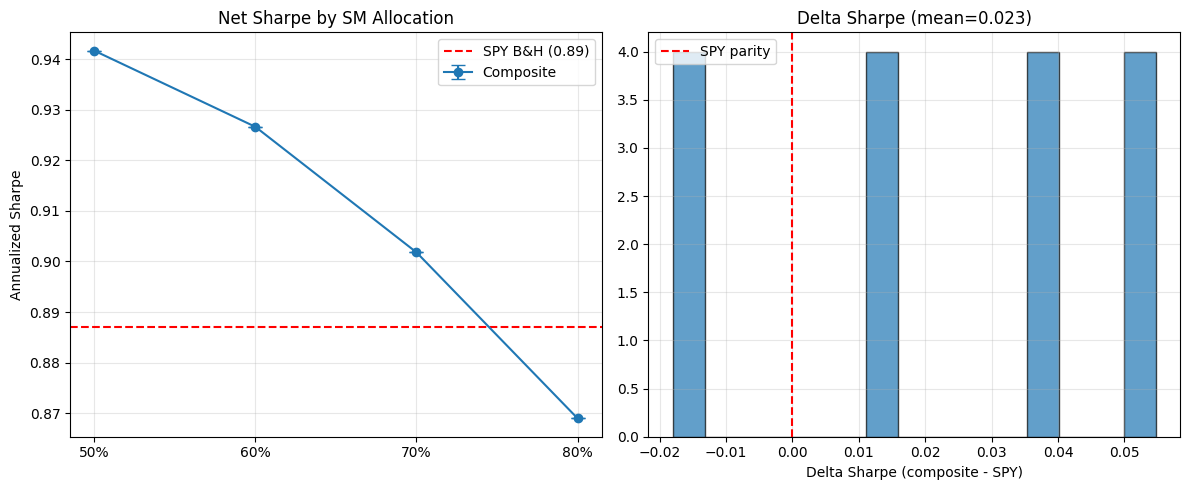

In [7]:
import matplotlib.pyplot as plt

if rows:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Sharpe by SM allocation
    allocs = sorted(set(r["sm_alloc"] for r in rows))
    mean_sharpes = [np.mean([r["sharpe_net"] for r in rows if r["sm_alloc"] == a]) for a in allocs]
    std_sharpes = [np.std([r["sharpe_net"] for r in rows if r["sm_alloc"] == a]) for a in allocs]
    
    axes[0].errorbar([f"{a:.0%}" for a in allocs], mean_sharpes, yerr=std_sharpes,
                    marker="o", capsize=5, label="Composite")
    spy_sharpe = rows[0]["sharpe_spy"]
    axes[0].axhline(y=spy_sharpe, color="red", linestyle="--", label=f"SPY B&H ({spy_sharpe:.2f})")
    axes[0].set_title("Net Sharpe by SM Allocation")
    axes[0].set_ylabel("Annualized Sharpe")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Delta distribution
    deltas = [r["sharpe_net"] - r["sharpe_spy"] for r in rows
              if not np.isnan(r["sharpe_net"]) and not np.isnan(r["sharpe_spy"])]
    axes[1].hist(deltas, bins=15, edgecolor="black", alpha=0.7)
    axes[1].axvline(x=0, color="red", linestyle="--", label="SPY parity")
    axes[1].set_title(f"Delta Sharpe (mean={np.mean(deltas):.3f})")
    axes[1].set_xlabel("Delta Sharpe (composite - SPY)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("composite_mom_regime_results.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("No data to plot")

## 7. Conclusion

Ce notebook combine SectorMomentum (composite momentum multi-lookback sur SPY/IEF/GLD) avec RegimeSwitching (filtre bull/bear/sideways adaptant l'allocation entre momentum et mean-reversion RSI). Le sweep SM50-RS50 a SM80-RS20 avec 4 seeds determine si la combinaison bat SPY B&H.

**Hypotheses testees** :
1. La decorrelation regime/momentum du composite ameliore le Sharpe vs chaque composant seul
2. Le filtre regime evite les pertes en bear market (TLT->IEF + defensive allocation)
3. Le composite momentum multi-lookback est plus robuste qu'un seul lookback

**Baseline** : SPY Buy & Hold.